# Grupo 17:

Alicia Mei García Morín (100498828)

Ana Grima Vázquez de Prada (100495785)

El objetivo de esta práctica es identificar tipos de estrellas utilizando técnicas de aprendizaje no supervisado.

En este notebook se realiza el preprocesado de los datos, la reducción de dimensionalidad con PCA, la aplicación y comparación de distintos algoritmos de clustering, y la interpretación de los grupos obtenidos.

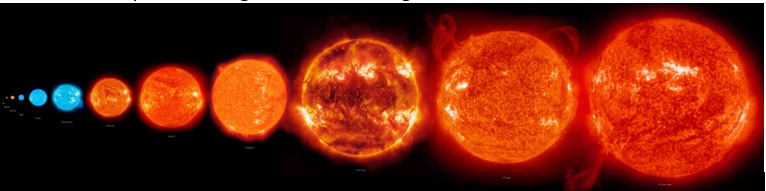

# 1. Carga de datos

En esta sección se cargan los datos que se utilizarán a lo largo de la práctica.



In [124]:
import pandas as pd
import numpy as np

SEED = 100498828
SEED_2 = 100498829
np.random.seed(SEED)

df = pd.read_csv("stars_data.csv")


# 2. EDA


## 2.1. Dimensiones del dataset


En esta sección se realiza un análisis exploratorio básico del dataset con el objetivo de entender su estructura y preparar el posterior preprocesamiento.

In [125]:
print("Dimensiones del dataset:", df.shape)
df.head()

Dimensiones del dataset: (240, 6)


,Temperature,L,R,A_M,Color,Spectral_Class
0,3068,0.002400,0.1700,16.12,Red,M
1,3042,0.000500,0.1542,16.60,Red,M
2,2600,0.000300,0.1020,18.70,Red,M
3,2800,0.000200,0.1600,16.65,Red,M
4,1939,0.000138,0.1030,20.06,Red,M


El dataset contiene:
- 240 instancias (filas) = número de estrellas
- 6 atributos (columnas) = número de atributos

In [126]:
df.dtypes


,0
Temperature,int64
L,float64
R,float64
A_M,float64
Color,object
Spectral_Class,object


In [127]:
categorical_columns = df.select_dtypes(include=["object"]).columns
numerical_columns   = df.select_dtypes(include=["int64","float64"]).columns

print("Categóricas:", list(categorical_columns))
print("Numéricas:", list(numerical_columns))

Categóricas: ['Color', 'Spectral_Class']
Numéricas: ['Temperature', 'L', 'R', 'A_M']


Se identifican 2 variables categóricas (de tipo objeto): `Color` y `Spectral_Class`

Y 4 variables numéricas (aquellas de tipo entero o flotante): `Temperature`, `L`, `R` y `A_M`.

El problema planteado corresponde a un problema de aprendizaje automático no supervisado (no hay variable objetivo), concretamente de clustering. El objetivo es agrupar las estrellas en función de sus características físicas y espectrales, identificando posibles grupos naturales en los datos.

## 2.2. Cardinalidad de variables categóricas

In [128]:
categorical_columns = df.select_dtypes(include=["object"]).columns
cardinality = df[categorical_columns].nunique()
cardinality

,0
Color,17
Spectral_Class,7


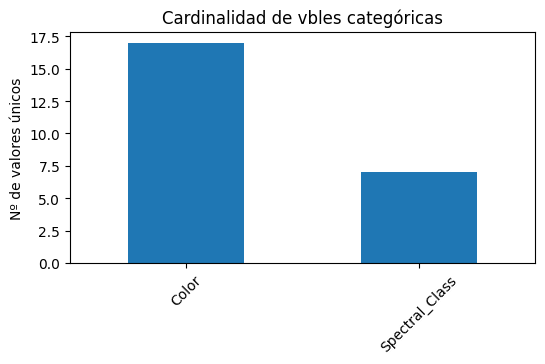

In [129]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,3))
cardinality.plot(kind="bar")
plt.title("Cardinalidad de vbles categóricas")
plt.ylabel("Nº de valores únicos")
plt.xticks(rotation=45)
plt.show()

Se observa que la variable `Color` presenta una mayor cardinalidad que `Spectral_Class`, ya que contiene un mayor número de valores distintos.

No obstante, esta cardinalidad puede considerarse moderada y manejable en el contexto del análisis.

Se normalizarán las categorías de la variable `Color` para unificar denominaciones equivalentes (por ejemplo, distintas formas de escribir un mismo color), y se hará una codificación ordinal tanto de `Color` como de `Spectral_Class`, teniendo en cuenta que ambas variables están relacionadas con la energía y temperatura de las estrellas.

## 2.3. Valores ausentes

In [130]:
print("How many missing values per attribute:")
print("======================================")
print(df.isnull().sum())

How many missing values per attribute:
Temperature       0
L                 0
R                 0
A_M               0
Color             0
Spectral_Class    0
dtype: int64


Observamos que ninguna variable presenta valores ausentes.

## 2.4 Columnas constantes o tipo ID

In [131]:
constant_cols = [col for col in df.columns if df[col].nunique() == 1]
print("Columnas constantes:", constant_cols)

id_cols = [col for col in df.columns if df[col].nunique() == len(df)]
print("Columnas tipo ID:", id_cols)

Columnas constantes: []
Columnas tipo ID: []


No se observan columnas constantes o columnas de ID.

## 2.5. Análisis de las variables numéricas

In [132]:
df[numerical_columns].describe()

,Temperature,L,R,A_M
count,240.000000,240.000000,240.000000,240.000000
mean,10497.462500,107188.361635,237.157781,4.382396
std,9552.425037,179432.244940,517.155763,10.532512
min,1939.000000,0.000080,0.008400,-11.920000
25%,3344.250000,0.000865,0.102750,-6.232500
50%,5776.000000,0.070500,0.762500,8.313000
75%,15055.500000,198050.000000,42.750000,13.697500
max,40000.000000,849420.000000,1948.500000,20.060000


Los estadísticos descriptivos muestran de nuevo que no existen valores faltantes en las variables numéricas.

Se observa además que las variables presentan escalas y rangos muy diferentes entre sí, lo que hace necesario aplicar un proceso de escalado antes de utilizar PCA y los algoritmos de clustering.

# 3. Preprocesamiento


## 3.1. Codificación de variables categóricas

El dataset contiene dos variables categóricas: `Color` y `Spectral_Class`.

La variable `Spectral_Class` tiene un orden físico natural, ya que la clasificación espectral ordena las estrellas desde las más calientes hasta las más frías: O, B, A, F, G, K, M. Por ello lo codificamos de forma ordinal.

La variable `Color` también está relacionada con la energía y temperatura de la estrella. Sin embargo, en el dataset aparecen distintas formas de escribir colores equivalentes, por lo que primero se normalizan estas categorías antes de codificarlas.

In [133]:
df_processed = df.copy()

df_processed["Color"] = (
    df_processed["Color"]
    .str.strip()
    .str.lower()
    .str.replace("-", " ", regex=False)
)

color_mapping = {
    "blue white": "blue white",
    "bluewhite": "blue white",
    "white": "white",
    "whitish": "white",
    "yellowish white": "yellow white",
    "yellow white": "yellow white",
    "white yellow": "yellow white",
    "yellowish": "yellow",
    "pale yellow orange": "orange",
    "orange red": "red",
    "red": "red",
    "orange": "orange",
    "blue": "blue"
}

df_processed["Color"] = df_processed["Color"].replace(color_mapping)

spectral_order = {
    "O": 0,
    "B": 1,
    "A": 2,
    "F": 3,
    "G": 4,
    "K": 5,
    "M": 6
}

color_order = {
    "blue": 0,
    "blue white": 1,
    "white": 2,
    "yellow white": 3,
    "yellow": 4,
    "orange": 5,
    "red": 6
}

df_processed["Spectral_Class_encoded"] = df_processed["Spectral_Class"].map(spectral_order)
df_processed["Color_encoded"] = df_processed["Color"].map(color_order)

df_processed.head()

,Temperature,L,R,A_M,Color,Spectral_Class,Spectral_Class_encoded,Color_encoded
0,3068,0.002400,0.1700,16.12,red,M,6,6
1,3042,0.000500,0.1542,16.60,red,M,6,6
2,2600,0.000300,0.1020,18.70,red,M,6,6
3,2800,0.000200,0.1600,16.65,red,M,6,6
4,1939,0.000138,0.1030,20.06,red,M,6,6


In [134]:
df_processed[["Color_encoded", "Spectral_Class_encoded"]].isnull().sum()

,0
Color_encoded,0
Spectral_Class_encoded,0


Se comprueba que la codificación de las variables categóricas no ha generado valores ausentes, por lo que todas las categorías han sido correctamente transformadas a valores numéricos.

# 3.2. Selección de variables

Una vez codificadas las variables categóricas, vamos a construir la matriz de entrada que se utilizará para el análisis no supervisado.

Esta matriz incluye tanto las variables numéricas originales como las variables categóricas codificadas ordinalmente.

In [135]:
X = df_processed[
    [
        "Temperature",
        "L",
        "R",
        "A_M",
        "Color_encoded",
        "Spectral_Class_encoded"
    ]
]

X.head()

,Temperature,L,R,A_M,Color_encoded,Spectral_Class_encoded
0,3068,0.002400,0.1700,16.12,6,6
1,3042,0.000500,0.1542,16.60,6,6
2,2600,0.000300,0.1020,18.70,6,6
3,2800,0.000200,0.1600,16.65,6,6
4,1939,0.000138,0.1030,20.06,6,6


## 3.3. Escalado de variables

Antes de aplicar PCA y los algoritmos de clustering, escalamos las variables mediante `StandardScaler`, ya que estos métodos son sensibles a las diferencias de escala entre variables.

In [136]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

## 3.4. Reducción de dimensionalidad mediante PCA

Para facilitar la visualización de los datos y la tarea de clustering, se aplica PCA con dos componentes principales, tal y como indica el enunciado.

A partir de este punto, los algoritmos de clustering se aplicarán directamente sobre estas dos componentes principales.

In [137]:
from sklearn.decomposition import PCA

pca = PCA(
    n_components=2,
    random_state=SEED
)

X_pca = pca.fit_transform(X_scaled)

X_pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

X_pca_clustering = X_pca_df[["PC1", "PC2"]]

X_pca_df.head()

,PC1,PC2
0,2.062933,-0.155353
1,2.082440,-0.173248
2,2.183931,-0.244008
3,2.096245,-0.169631
4,2.268088,-0.281221


In [138]:
explained_variance = pca.explained_variance_ratio_

print("Varianza explicada PC1:", round(explained_variance[0], 3))
print("Varianza explicada PC2:", round(explained_variance[1], 3))
print("Varianza total explicada (%):", round(explained_variance.sum() * 100, 2))

Varianza explicada PC1: 0.558
Varianza explicada PC2: 0.296
Varianza total explicada (%): 85.33


Las dos primeras componentes principales explican aproximadamente el 85.33% de la varianza total del dataset. Esto permite reducir la dimensionalidad a dos componentes manteniendo una parte relevante de la información original, tal y como requiere el enunciado.

A continuación, se representa gráficamente la proyección de las estrellas en las dos primeras componentes principales. Esta visualización permite observar posibles agrupaciones naturales antes de aplicar los algoritmos de clustering.

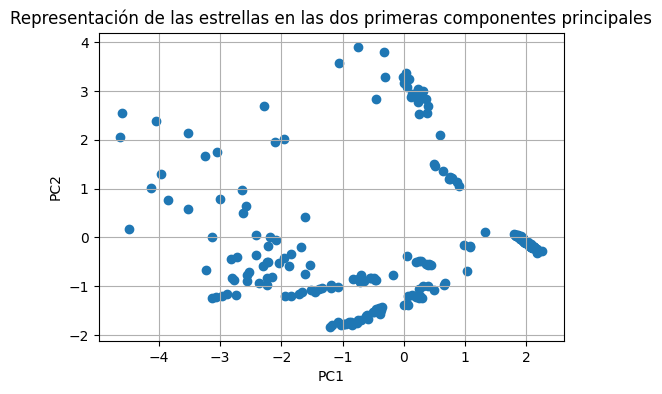

In [139]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))

plt.scatter(
    X_pca_df["PC1"],
    X_pca_df["PC2"]
)

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.title("Representación de las estrellas en las dos primeras componentes principales")

plt.grid(True)

plt.show()

Esto sugiere que los algoritmos de clustering pueden identificar grupos de estrellas con características similares. Por tanto, se procede a aplicar los métodos de clustering sobre estas dos componentes principales.

# 4. K-Means

## 4.1. Selección del número de clusters




Se aplica el algoritmo K-Means sobre las dos componentes principales obtenidas mediante PCA.

Para seleccionar el número adecuado de clusters se utilizan dos métricas:

- Inercia (Elbow method)
- Silhouette score

Estas métricas permiten evaluar la calidad de los agrupamientos obtenidos y seleccionar el número de clusters más adecuado.

In [140]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertia = []
silhouette_scores = []

K_range = range(2, 11)

for k in K_range:

    kmeans = KMeans(
        n_clusters=k,
        random_state=SEED,
        n_init=10
    )

    labels = kmeans.fit_predict(X_pca_clustering)

    inertia.append(kmeans.inertia_)

    silhouette_scores.append(
        silhouette_score(X_pca_clustering, labels)
    )

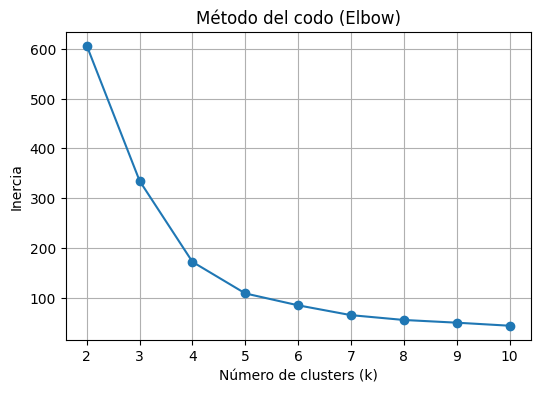

In [141]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))

plt.plot(
    K_range,
    inertia,
    marker="o"
)

plt.xlabel("Número de clusters (k)")
plt.ylabel("Inercia")

plt.title("Método del codo (Elbow)")

plt.grid(True)

plt.show()

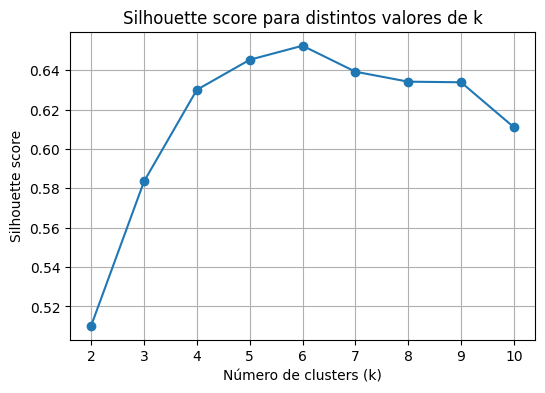

In [142]:
plt.figure(figsize=(6, 4))

plt.plot(
    K_range,
    silhouette_scores,
    marker="o"
)

plt.xlabel("Número de clusters (k)")
plt.ylabel("Silhouette score")

plt.title("Silhouette score para distintos valores de k")

plt.grid(True)

plt.show()

A partir del gráfico del método del codo (Elbow), se observa una reducción significativa de la inercia al aumentar el número de clusters desde k=2 hasta k=4 o k=5. A partir de ese punto, la disminución de la inercia se vuelve más gradual, lo que sugiere la presencia de un posible "codo" en torno a esos valores.

Por otro lado, el análisis del silhouette score muestra que el valor máximo se alcanza para k=6, lo que indica que esta configuración proporciona la mejor separación y cohesión entre los clusters en comparación con el resto de valores evaluados.

Teniendo en cuenta ambas métricas, se selecciona **k=6** como número de clusters para aplicar el algoritmo **K-Means**, ya que combina una buena reducción de la inercia con el mayor valor de silhouette score, lo que sugiere una estructura de agrupamiento adecuada en los datos.

## 4.2. Aplicación final de K-Means

In [143]:
kmeans = KMeans(
    n_clusters=6,
    random_state=SEED,
    n_init=10
)

kmeans_labels = kmeans.fit_predict(X_pca_clustering)

silhouette_kmeans_final = silhouette_score(
    X_pca_clustering,
    kmeans_labels
)

print("Silhouette score final:", round(silhouette_kmeans_final, 3))

X_pca_df["cluster_kmeans"] = kmeans_labels

Silhouette score final: 0.652


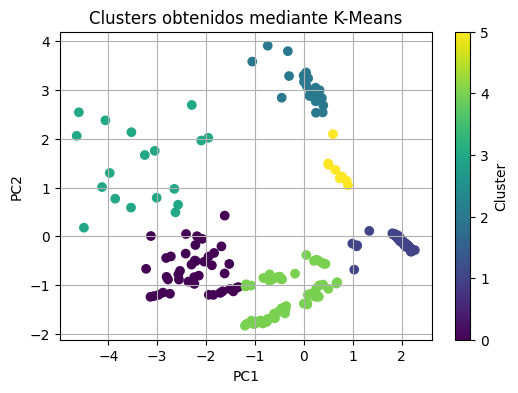

In [144]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.scatter(
    X_pca_df["PC1"],
    X_pca_df["PC2"],
    c=X_pca_df["cluster_kmeans"],
    cmap="viridis"
)

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.title("Clusters obtenidos mediante K-Means")

plt.colorbar(label="Cluster")

plt.grid(True)

plt.show()

La representación gráfica de los datos en el espacio de las dos primeras componentes principales muestra que el algoritmo K-Means ha identificado **seis grupos diferenciados de estrellas**.

Se observa que los clusters están relativamente bien separados entre sí, lo que indica que el número de clusters seleccionado (k=6) permite capturar adecuadamente la estructura de los datos. Cada color representa un grupo de estrellas con características similares en términos de temperatura, luminosidad, radio y magnitud absoluta.

Estos resultados sugieren que el algoritmo K-Means es capaz de segmentar las estrellas en grupos coherentes, lo que facilita la posterior interpretación y caracterización de los distintos tipos de estrellas.

# 5. Hierarchical Clustering/Dendrogramas

Se aplica clustering jerárquico sobre las dos componentes principales obtenidas mediante PCA.

En primer lugar, se construye un dendrograma utilizando el método de linkage Ward para analizar la posible estructura jerárquica de los datos y estimar un número adecuado de clusters.

Posteriormente, se aplica Agglomerative Clustering y se evalúan distintos números de clusters mediante silhouette score.

## 5.1. Dendrograma


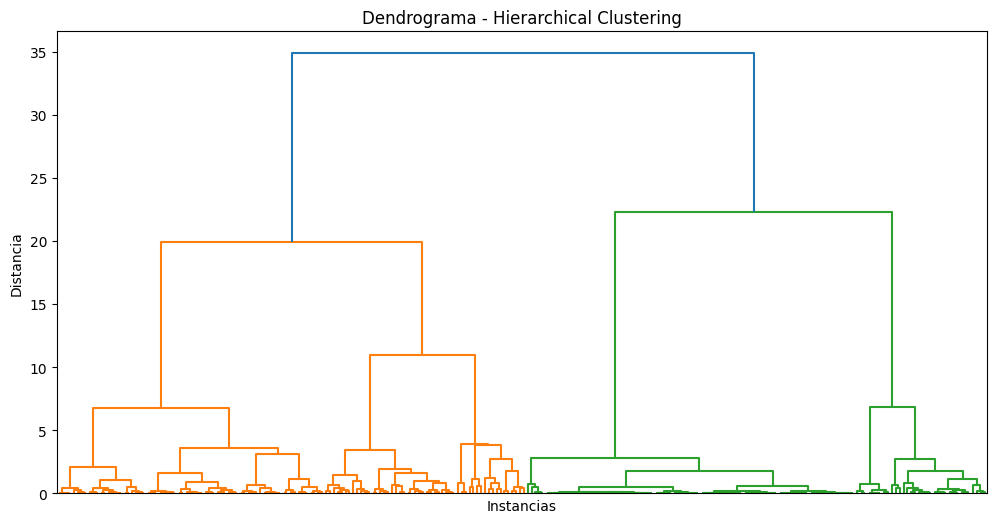

In [145]:
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

linked = linkage(
    X_pca_df[["PC1", "PC2"]],
    method="ward"
)

plt.figure(figsize=(12, 6))

dendrogram(
    linked,
    no_labels=True
)

plt.title("Dendrograma - Hierarchical Clustering")
plt.xlabel("Instancias")
plt.ylabel("Distancia")

plt.show()

Con este visualizamos la estructura jerárquica de los datos y observamos posibles agrupaciones naturales.

Se aprecia la existencia de varios grupos diferenciados, lo que sugiere que un número de clusters cercano a 5 o 6 podría ser adecuado, en línea con los resultados obtenidos previamente mediante K-Means.

## 5.2. Selección del número de clusters

In [146]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

silhouette_scores_h = []

K_range = range(2, 11)

for k in K_range:

    agglo = AgglomerativeClustering(
        n_clusters=k,
        linkage="ward"
    )

    labels = agglo.fit_predict(
        X_pca_clustering
    )

    score = silhouette_score(
        X_pca_clustering,
        labels
    )

    silhouette_scores_h.append(score)

best_k_h = K_range[np.argmax(silhouette_scores_h)]

print("Mejor número de clusters:", best_k_h)
print(
    "Mejor silhouette score:",
    round(max(silhouette_scores_h), 3)
)

Mejor número de clusters: 6
Mejor silhouette score: 0.635


Para seleccionar el número de clusters más adecuado, se evalúa el silhouette score para distintos valores de `n_clusters`.

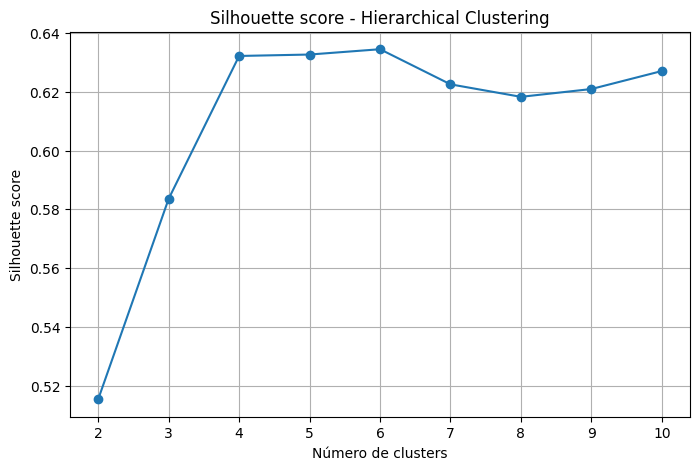

In [147]:
plt.figure(figsize=(8, 5))

plt.plot(
    K_range,
    silhouette_scores_h,
    marker="o"
)

plt.xlabel("Número de clusters")
plt.ylabel("Silhouette score")

plt.title("Silhouette score - Hierarchical Clustering")

plt.grid(True)

plt.show()

Se observa que los mejores resultados se obtienen para valores cercanos a 6 clusters, lo que resulta consistente con los resultados obtenidos previamente mediante K-Means.

## 5.3. Aplicación final de Hierarchical Clustering

In [148]:
agglo_final = AgglomerativeClustering(
    n_clusters=6,
    linkage="ward"
)

agglo_labels = agglo_final.fit_predict(
    X_pca_df[["PC1", "PC2"]]
)

X_pca_df["cluster_hierarchical"] = agglo_labels

silhouette_h_final = silhouette_score(
    X_pca_df[["PC1", "PC2"]],
    agglo_labels
)

print(
    "Silhouette score final:",
    round(silhouette_h_final, 3)
)

Silhouette score final: 0.635


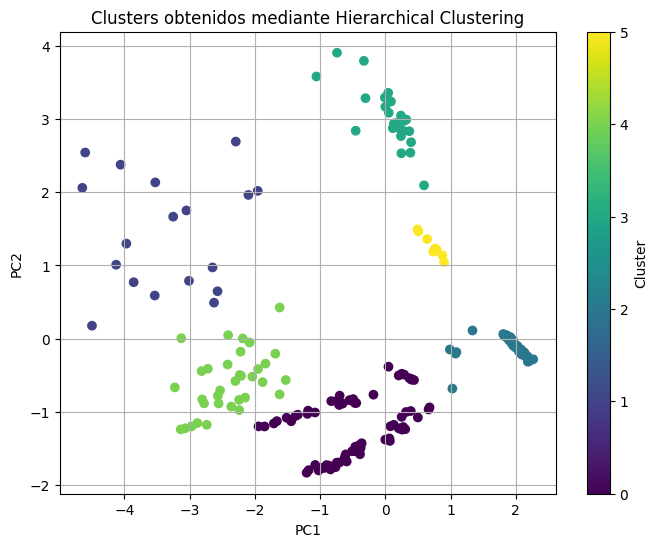

In [149]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_pca_df["PC1"],
    X_pca_df["PC2"],
    c=X_pca_df["cluster_hierarchical"],
    cmap="viridis"
)

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.title("Clusters obtenidos mediante Hierarchical Clustering")

plt.colorbar(label="Cluster")

plt.grid(True)

plt.show()

La representación gráfica muestra una separación relativamente clara entre clusters y el silhouette score obtenido indica una buena calidad de agrupamiento.

Además, los resultados obtenidos son consistentes con los obtenidos previamente mediante K-Means, lo que refuerza la existencia de una estructura de agrupamiento estable en los datos.

# 6. DBSCAN


## 6.1. Selección inicial de hiperparámetros

Para seleccionar un valor adecuado de `eps`, se utiliza el gráfico de distancias a los vecinos más cercanos (k-distance plot).

Asimismo, se probarán distintos valores de `min_samples`, ya que este parámetro controla el número mínimo de vecinos necesarios para formar una región densa.

Dado que el clustering se realiza sobre un espacio reducido a dos dimensiones mediante PCA, se consideran valores pequeños de `min_samples`, siguiendo las recomendaciones habituales para DBSCAN.

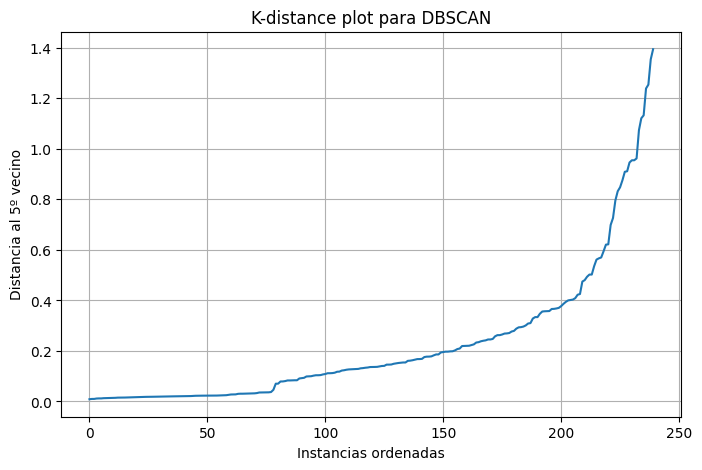

In [150]:
from sklearn.neighbors import NearestNeighbors
import numpy as np
import matplotlib.pyplot as plt

neighbors = NearestNeighbors(n_neighbors=5)

neighbors_fit = neighbors.fit(
    X_pca_df[["PC1", "PC2"]]
)

distances, indices = neighbors_fit.kneighbors(
    X_pca_df[["PC1", "PC2"]]
)

distances = np.sort(distances[:, 4])

plt.figure(figsize=(8, 5))

plt.plot(distances)

plt.xlabel("Instancias ordenadas")
plt.ylabel("Distancia al 5º vecino")

plt.title("K-distance plot para DBSCAN")

plt.grid(True)

plt.show()

El gráfico muestra un cambio progresivo de pendiente aproximadamente entre valores de distancia de 0.25 y 0.45.

Esto sugiere que valores de `eps` dentro de ese rango podrían ser adecuados para DBSCAN, ya que separan regiones densas de posibles puntos aislados o ruido.

Por ello, se evaluarán distintos valores de `eps` comprendidos aproximadamente entre 0.2 y 0.45.

Aunque el k-distance plot se representa tomando como referencia el 5º vecino, más adelante se evalúan distintos valores de `min_samples` para comprobar la sensibilidad del algoritmo ante este hiperparámetro.



## 6.2. Evaluación de distintas configuraciones

Se evalúan distintas combinaciones de `eps` y `min_samples` para analizar cómo afectan al número de clusters, al número de puntos considerados ruido y a la calidad del clustering.

Para evaluar los resultados se utilizarán silhouette score y DBCV.

In [151]:
!pip install hdbscan
%pip install hdbscan

In [152]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
from hdbscan.validity import validity_index

eps_values = [0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5]

min_samples_values = [3, 4, 5, 6, 8]

results_dbscan = []

for min_samples in min_samples_values:

    for eps in eps_values:

        dbscan = DBSCAN(
            eps=eps,
            min_samples=min_samples
        )

        labels = dbscan.fit_predict(
            X_pca_clustering
        )

        n_clusters = len(set(labels)) - (
            1 if -1 in labels else 0
        )

        n_noise = list(labels).count(-1)

        if n_clusters > 1:

            mask = labels != -1

            silhouette = silhouette_score(
                X_pca_df.loc[mask, ["PC1", "PC2"]],
                labels[mask]
            )

            dbcv = validity_index(
                X_pca_clustering.values,
                labels
            )

        else:

            silhouette = np.nan
            dbcv = np.nan

        results_dbscan.append([
            eps,
            min_samples,
            n_clusters,
            n_noise,
            silhouette,
            dbcv
        ])

In [153]:
results_dbscan_df = pd.DataFrame(
    results_dbscan,
    columns=[
        "eps",
        "min_samples",
        "n_clusters",
        "noise_points",
        "silhouette",
        "DBCV"
    ]
)

results_dbscan_df = results_dbscan_df.round(3)

results_dbscan_df

,eps,min_samples,n_clusters,noise_points,silhouette,DBCV
0,0.20,3,13,39,0.704,0.625
1,0.25,3,13,34,0.687,0.620
2,0.30,3,9,32,0.670,0.617
3,0.35,3,9,25,0.590,0.597
4,0.40,3,9,20,0.539,0.529
5,0.45,3,7,17,0.476,0.488
6,0.50,3,5,12,0.135,0.397
7,0.20,4,11,51,0.759,0.613
8,0.25,4,12,38,0.723,0.624
9,0.30,4,8,35,0.702,0.622


Los resultados muestran que DBSCAN es bastante sensible a los hiperparámetros `eps` y `min_samples`. En general, valores pequeños de `eps` generan un mayor número de clusters y una mayor cantidad de puntos considerados ruido, mientras que valores más altos tienden a fusionar agrupaciones y reducir el número de clusters detectados.

Asimismo, al aumentar `min_samples`, el algoritmo se vuelve más restrictivo y aumenta el número de puntos clasificados como ruido.

Se observa que las mejores configuraciones según DBCV se obtienen para valores altos de `eps` (0.45), aunque en estos casos el número de clusters detectados es relativamente pequeño. Por otro lado, configuraciones con valores intermedios de `eps` generan un mayor número de clusters y mantienen métricas de calidad razonablemente altas.

In [154]:
results_dbscan_df.sort_values(
    by="DBCV",
    ascending=False
).head()

,eps,min_samples,n_clusters,noise_points,silhouette,DBCV
26,0.45,6,4,29,0.681,0.656
19,0.45,5,4,29,0.681,0.656
23,0.30,6,10,40,0.723,0.631
31,0.35,8,9,42,0.731,0.630
0,0.20,3,13,39,0.704,0.625


Aunque la configuración con `eps = 0.45` obtiene el mayor valor de DBCV, genera únicamente 4 clusters, fusionando agrupaciones que visualmente parecen diferenciadas.

Por ello, se selecciona finalmente la configuración `eps = 0.30` y `min_samples = 6`, ya que proporciona un equilibrio más razonable entre calidad del clustering, número de clusters obtenidos y capacidad de separación entre grupos.

## 6.3. Modelo final DBSCAN

In [155]:
dbscan_final = DBSCAN(
    eps=0.3,
    min_samples=6
)

dbscan_labels = dbscan_final.fit_predict(
    X_pca_clustering
)

X_pca_df["cluster_dbscan"] = dbscan_labels

In [156]:
n_clusters_final = len(set(dbscan_labels)) - (
    1 if -1 in dbscan_labels else 0
)

n_noise_final = list(dbscan_labels).count(-1)

mask = dbscan_labels != -1

silhouette_dbscan = silhouette_score(
    X_pca_df.loc[mask, ["PC1", "PC2"]],
    dbscan_labels[mask]
)

dbcv_final = validity_index(
    X_pca_clustering.values,
    dbscan_labels
)

print("Número de clusters:", n_clusters_final)
print("Número de puntos ruido:", n_noise_final)
print("Silhouette score:", round(silhouette_dbscan, 3))
print("DBCV:", round(dbcv_final, 3))

Número de clusters: 10
Número de puntos ruido: 40
Silhouette score: 0.723
DBCV: 0.631


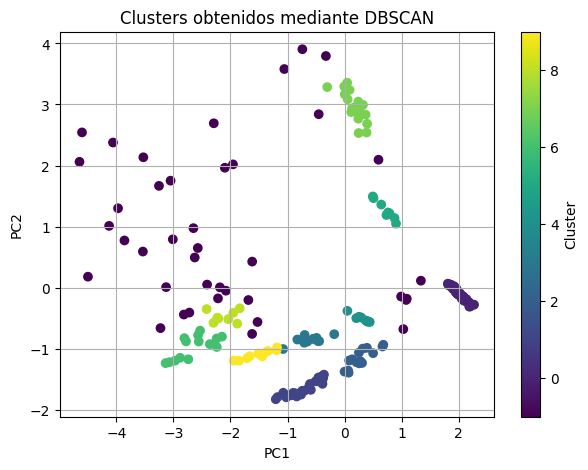

In [157]:
plt.figure(figsize=(7, 5))

plt.scatter(
    X_pca_df["PC1"],
    X_pca_df["PC2"],
    c=X_pca_df["cluster_dbscan"],
    cmap="viridis"
)

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.title("Clusters obtenidos mediante DBSCAN")

plt.colorbar(label="Cluster")

plt.grid(True)

plt.show()

Con la configuración seleccionada (`eps = 0.30`, `min_samples = 6`), DBSCAN identifica varios grupos densos en el espacio PCA y clasifica algunas observaciones como ruido.

Este comportamiento es coherente con la naturaleza del algoritmo, ya que DBSCAN no impone un número fijo de clusters y permite detectar puntos aislados. En la gráfica se observa que algunos grupos compactos quedan bien diferenciados, aunque también aparecen bastantes observaciones etiquetadas como ruido.

Por tanto, DBSCAN resulta útil para identificar estructuras locales y posibles valores atípicos, pero sus resultados son menos directos de interpretar que los obtenidos con K-Means o Hierarchical Clustering, que producen una partición más estable y cercana a los seis tipos de estrellas considerados en la tabla astronómica.

# 7. Resultados


## 7.1. Comparativa de algoritmos

Una vez aplicados los tres algoritmos de clustering, se comparan los resultados obtenidos para analizar cuál proporciona una agrupación más adecuada de las estrellas.

La comparación se realiza teniendo en cuenta:

- número de clusters obtenidos
- calidad del agrupamiento mediante silhouette score
- interpretabilidad de los grupos
- presencia de ruido, en el caso de DBSCAN

In [158]:
comparison_results = pd.DataFrame({
    "Algoritmo": [
        "K-Means",
        "Hierarchical Clustering",
        "DBSCAN"
    ],

    "Hiperparámetros": [
        "k = 6",
        "n_clusters = 6, linkage = ward",
        "eps = 0.30, min_samples = 6"
    ],

    "Nº clusters": [
        6,
        6,
        n_clusters_final
    ],

    "Ruido": [
        0,
        0,
        n_noise_final
    ],

    "Silhouette": [
        round(silhouette_kmeans_final, 3),
        round(silhouette_h_final, 3),
        round(silhouette_dbscan, 3)
    ],

    "DBCV": [
        np.nan,
        np.nan,
        round(dbcv_final, 3)
    ],

    "Interpretabilidad": [
        "Alta",
        "Alta",
        "Media"
    ]
})

comparison_results

,Algoritmo,Hiperparámetros,Nº clusters,Ruido,Silhouette,DBCV,Interpretabilidad
0,K-Means,k = 6,6,0,0.652,NaN,Alta
1,Hierarchical Clustering,"n_clusters = 6, linkage = ward",6,0,0.635,NaN,Alta
2,DBSCAN,"eps = 0.30, min_samples = 6",10,40,0.723,0.631,Media


Aunque DBSCAN obtiene el mayor silhouette score, este resultado debe interpretarse con cautela, ya que el algoritmo genera un número elevado de clusters y además clasifica 40 observaciones como ruido.

Por el contrario, K-Means y Hierarchical Clustering producen una partición más estable e interpretable de los datos, obteniendo 6 clusters claramente diferenciados y coherentes con los tipos de estrellas descritos en astronomía.

Además, K-Means ofrece una solución especialmente sencilla y eficiente para asignar nuevas observaciones a un cluster, por lo que se considera el método más adecuado como pipeline final para este problema.

## 7.2. Pipeline recomendado


A partir de los resultados obtenidos, se recomienda utilizar el siguiente pipeline de clustering:
```
1. Codificación ordinal de las variables categóricas Color y Spectral_Class.
2. StandardScaler sobre todas las variables.
3. Reducción de dimensionalidad mediante PCA con 2 componentes principales.
4. Aplicación de K-Means con k = 6.
```
Se selecciona K-Means como método final porque proporciona una agrupación clara, estable y fácilmente interpretable. Además, el número de clusters seleccionado está justificado por las métricas internas utilizadas durante el ajuste y resulta coherente con la tabla de tipos astronómicos proporcionada en el enunciado.

Aunque Hierarchical Clustering obtiene resultados similares, K-Means ofrece una solución más sencilla y directa para asignar nuevas observaciones a un cluster. DBSCAN, en cambio, resulta útil para detectar posibles puntos atípicos, pero sus resultados son más sensibles a los hiperparámetros y menos adecuados como partición final principal.

In [159]:
recommended_labels = X_pca_df["cluster_kmeans"]

df_clusters = df_processed.copy()
df_clusters["cluster"] = recommended_labels

df_clusters.head()

,Temperature,L,R,A_M,Color,Spectral_Class,Spectral_Class_encoded,Color_encoded,cluster
0,3068,0.002400,0.1700,16.12,red,M,6,6,1
1,3042,0.000500,0.1542,16.60,red,M,6,6,1
2,2600,0.000300,0.1020,18.70,red,M,6,6,1
3,2800,0.000200,0.1600,16.65,red,M,6,6,1
4,1939,0.000138,0.1030,20.06,red,M,6,6,1


# 8. Caracterización de los clusters obtenidos

Una vez seleccionado K-Means como pipeline recomendado, se caracterizan los clusters obtenidos analizando las variables originales del dataset.

Para ello se estudian los valores de temperatura, luminosidad, radio y magnitud absoluta en cada cluster. Además, se analiza la distribución de las variables categóricas `Color` y `Spectral_Class`.

El objetivo es interpretar si los grupos encontrados por el algoritmo se corresponden con tipos de estrellas con propiedades físicas diferenciadas.

In [160]:
cluster_summary_numeric = df_clusters.groupby("cluster")[
    ["Temperature", "L", "R", "A_M"]
].agg(["mean", "median", "std"])

cluster_summary_numeric.round(3)

Temperature                               L                          \
               mean   median        std        mean      median         std   
cluster                                                                       
0         21793.357  22675.0   9028.454  203221.857  203450.000  128973.513   
1          3261.129   3192.0    639.291       0.017       0.001       0.080   
2          3782.375   3612.0    682.220  245541.667  219000.000  128276.867   
3         24015.889  24317.5  10965.526  512365.611  471216.500  241750.727   
4         12608.902  12098.0   4879.765     136.169       0.001     332.236   
5          3466.800   3574.5    247.385  206600.000  197500.000   84689.236   

                R                        A_M                 
             mean    median      std    mean  median    std  
cluster                                                      
0          52.884    35.000  107.882  -5.553  -5.908  1.289  
1           0.259     0.160    0.219  14.593  14.776  3.430  
2        1391.875  1384.500  179.158  -9.916 -10.700  1.538  
3        1105.389  1223.000  632.526  -8.731  -8.570  1.570  
4           1.274     0.012    2.223   8.323  11.380  5.969  
5         129.500    37.000  263.958  -6.798  -6.670  1.341

In [161]:
cluster_summary_cat = df_clusters.groupby("cluster").agg({
    "Color": lambda x: x.mode()[0],
    "Spectral_Class": lambda x: x.mode()[0]
})

cluster_summary_cat

,Color,Spectral_Class
cluster,,
0,blue,O
1,red,M
2,red,M
3,blue,O
4,blue white,B
5,red,M


In [162]:
cluster_profile = df_clusters.groupby("cluster").agg({
    "Temperature": "median",
    "L": "median",
    "R": "median",
    "A_M": "median",
    "Color": lambda x: x.mode()[0],
    "Spectral_Class": lambda x: x.mode()[0]
}).reset_index()

cluster_profile.round(3)

,cluster,Temperature,L,R,A_M,Color,Spectral_Class
0,0,22675.0,203450.000,35.000,-5.908,blue,O
1,1,3192.0,0.001,0.160,14.776,red,M
2,2,3612.0,219000.000,1384.500,-10.700,red,M
3,3,24317.5,471216.500,1223.000,-8.570,blue,O
4,4,12098.0,0.001,0.012,11.380,blue white,B
5,5,3574.5,197500.000,37.000,-6.670,red,M


La tabla anterior resume el perfil típico de cada cluster utilizando la mediana de las variables numéricas y la moda de las variables categóricas.

Se utiliza la mediana porque algunas variables, especialmente la luminosidad y el radio, presentan rangos muy amplios y valores extremos. De esta forma, la caracterización de cada cluster resulta más robusta.

A continuación se representan boxplots de las variables numéricas originales para analizar cómo se distribuyen dentro de cada cluster.

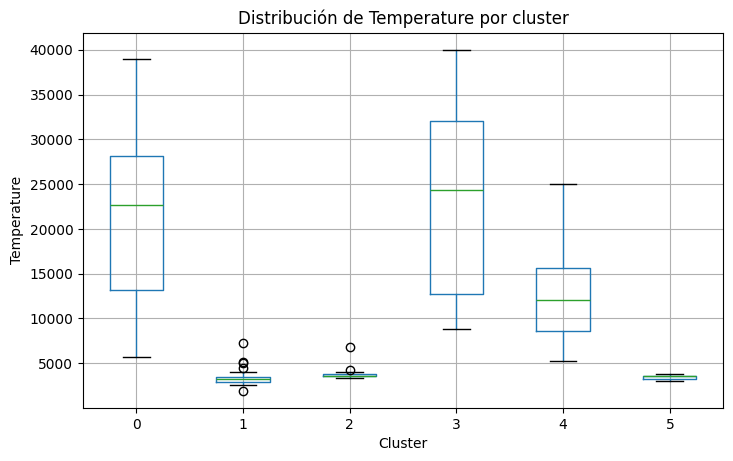

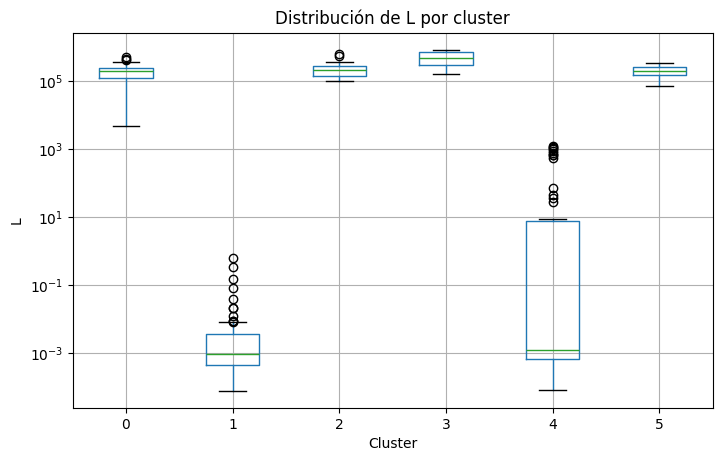

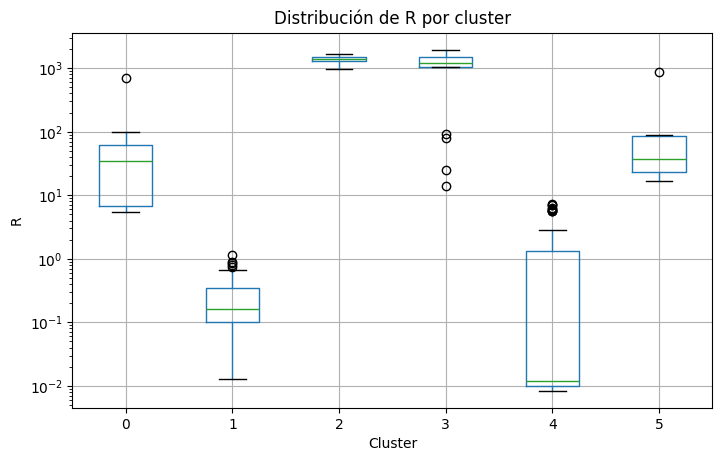

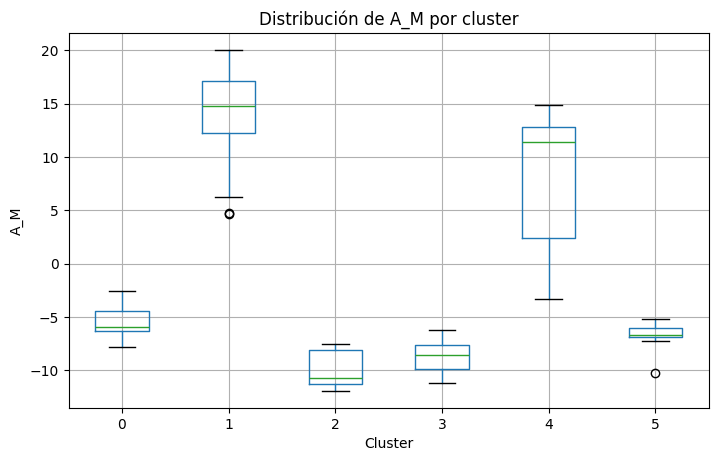

In [163]:
import matplotlib.pyplot as plt

numeric_vars = ["Temperature", "L", "R", "A_M"]

for var in numeric_vars:
    ax = df_clusters.boxplot(
        column=var,
        by="cluster",
        grid=True,
        figsize=(8, 5)
    )

    ax.set_title(f"Distribución de {var} por cluster")
    ax.set_xlabel("Cluster")
    ax.set_ylabel(var)

    if var in ["L", "R"]:
        ax.set_yscale("log")

    plt.suptitle("")
    plt.show()

Los boxplots muestran que los clusters presentan perfiles diferenciados en las variables físicas de las estrellas.

Algunos clusters se caracterizan por temperaturas más elevadas, otros por mayores valores de luminosidad o radio, y otros por magnitudes absolutas más altas. Esto indica que la agrupación obtenida no es arbitraria, sino que separa estrellas con propiedades físicas distintas.

En particular, las variables `L`, `R` y `A_M` resultan especialmente útiles para distinguir entre estrellas pequeñas y poco luminosas, estrellas de secuencia principal y estrellas gigantes o supergigantes.

A continuación se analiza la distribución de las variables categóricas por cluster mediante tablas de frecuencia relativas.

In [164]:
pd.crosstab(
    df_clusters["cluster"],
    df_clusters["Spectral_Class"],
    normalize="index"
).round(3)

Spectral_Class,A,B,F,G,K,M,O
cluster,,,,,,,
0,0.000,0.286,0.000,0.000,0.000,0.000,0.714
1,0.000,0.000,0.012,0.000,0.047,0.941,0.000
2,0.000,0.000,0.000,0.042,0.083,0.875,0.000
3,0.111,0.333,0.000,0.000,0.000,0.000,0.556
4,0.279,0.459,0.262,0.000,0.000,0.000,0.000
5,0.000,0.000,0.000,0.000,0.000,1.000,0.000


In [165]:
pd.crosstab(
    df_clusters["cluster"],
    df_clusters["Color"],
    normalize="index"
).round(3)

Color,blue,blue white,orange,red,white,yellow,yellow white
cluster,,,,,,,
0,0.762,0.238,0.000,0.000,0.000,0.000,0.000
1,0.000,0.000,0.012,0.953,0.000,0.035,0.000
2,0.000,0.000,0.083,0.917,0.000,0.000,0.000
3,0.611,0.278,0.000,0.000,0.111,0.000,0.000
4,0.213,0.426,0.000,0.000,0.164,0.000,0.197
5,0.000,0.000,0.000,1.000,0.000,0.000,0.000


Las tablas de frecuencia permiten analizar qué colores y clases espectrales predominan en cada cluster.

Esto es relevante porque tanto el color como la clase espectral están relacionados con la temperatura y la energía de las estrellas. Por tanto, si los clusters presentan colores o clases espectrales dominantes, esto refuerza la interpretación física de los grupos obtenidos.

# 9. Comparación con las clases astronómicas

In [166]:
astro_reference = pd.DataFrame({
    "Clase astronómica": [
        "Enana roja",
        "Enana marrón",
        "Enana blanca",
        "Secuencia principal",
        "Super gigante",
        "Hiper gigante"
    ],
    "Temperature": [
        3000,
        3300,
        14000,
        16000,
        15000,
        11000
    ],
    "L": [
        7.0e-4,
        5.5e-3,
        2.5e-3,
        3.2e4,
        3.0e5,
        3.0e5
    ],
    "R": [
        1.0e-1,
        3.5e-1,
        1.0e-2,
        4.4,
        5.0e1,
        1.4e3
    ],
    "A_M": [
        17.5,
        12.5,
        12.6,
        -0.4,
        -6.4,
        -9.6
    ],
    "Color": [
        "red",
        "red",
        "white",
        "white/yellow",
        "white/yellow",
        "yellow"
    ],
    "Spectral_Class": [
        "K-M",
        "M",
        "B-G",
        "B-M",
        "B-M",
        "B-M"
    ]
})

astro_reference

,Clase astronómica,Temperature,L,R,A_M,Color,Spectral_Class
0,Enana roja,3000,0.0007,0.10,17.5,red,K-M
1,Enana marrón,3300,0.0055,0.35,12.5,red,M
2,Enana blanca,14000,0.0025,0.01,12.6,white,B-G
3,Secuencia principal,16000,32000.0000,4.40,-0.4,white/yellow,B-M
4,Super gigante,15000,300000.0000,50.00,-6.4,white/yellow,B-M
5,Hiper gigante,11000,300000.0000,1400.00,-9.6,yellow,B-M


In [167]:
cluster_profile.round(3)

,cluster,Temperature,L,R,A_M,Color,Spectral_Class
0,0,22675.0,203450.000,35.000,-5.908,blue,O
1,1,3192.0,0.001,0.160,14.776,red,M
2,2,3612.0,219000.000,1384.500,-10.700,red,M
3,3,24317.5,471216.500,1223.000,-8.570,blue,O
4,4,12098.0,0.001,0.012,11.380,blue white,B
5,5,3574.5,197500.000,37.000,-6.670,red,M


Al comparar los perfiles de los clusters obtenidos mediante K-Means con la tabla astronómica de referencia, se observan similitudes claras entre varios grupos encontrados por el algoritmo y las clases de estrellas utilizadas habitualmente en astronomía.

Por ejemplo, algunos clusters presentan temperaturas bajas, color rojo, luminosidad reducida y magnitudes absolutas elevadas, características asociadas a estrellas tipo enana roja o enana marrón.

Asimismo, aparecen clusters con temperaturas muy elevadas, colores azulados o blanco-azulados y radios pequeños, que recuerdan a las enanas blancas.

También se identifican grupos con luminosidades y radios extremadamente altos, junto con magnitudes absolutas negativas, compatibles con estrellas gigantes, supergigantes o hipergigantes.

Aunque la correspondencia no es exacta, ya que el clustering se ha realizado de forma completamente no supervisada y utilizando únicamente similitudes entre atributos, los resultados muestran que el algoritmo ha sido capaz de descubrir agrupaciones coherentes con propiedades físicas reales de las estrellas.

Esto sugiere que las variables del dataset contienen una estructura natural bien definida y que el pipeline seleccionado permite capturar dicha estructura de forma razonablemente interpretable.

# 10. Conclusión final

En esta práctica se han aplicado técnicas de aprendizaje no supervisado para identificar grupos naturales de estrellas a partir de sus características físicas y espectrales.

En primer lugar, se realizó un preprocesamiento de los datos, codificando de forma ordinal las variables categóricas `Color` y `Spectral_Class`, ya que ambas están relacionadas con la temperatura y la energía de las estrellas. Posteriormente, se escalaron las variables y se aplicó PCA con 2 componentes principales, tal y como indicaba el enunciado.

Sobre el espacio reducido mediante PCA se aplicaron tres algoritmos de clustering: K-Means, Hierarchical Clustering y DBSCAN.

K-Means permitió obtener una partición clara en 6 clusters, seleccionados a partir del método del codo y del silhouette score. Hierarchical Clustering produjo resultados similares, reforzando la existencia de una estructura de agrupamiento estable en los datos. DBSCAN, por su parte, permitió detectar agrupaciones basadas en densidad y posibles puntos considerados ruido, aunque sus resultados fueron más sensibles a los hiperparámetros.

A partir de la comparación global de los métodos, se recomienda como pipeline final el formado por codificación ordinal, escalado, PCA con 2 componentes y K-Means con `k = 6`.

La caracterización de los clusters mediante estadísticos descriptivos, tablas de frecuencia y boxplots muestra que los grupos obtenidos presentan diferencias claras en temperatura, luminosidad, radio, magnitud absoluta, color y clase espectral. Además, al comparar estos grupos con la tabla astronómica proporcionada, se observan similitudes razonables con tipos de estrellas conocidos, como enanas, estrellas de secuencia principal y estrellas gigantes.

Por tanto, los resultados obtenidos muestran que las técnicas de clustering permiten descubrir una estructura interpretable en el dataset y agrupar las estrellas de forma coherente con sus propiedades físicas.

# Utilización de IA

Durante la realización de esta práctica hemos utilizado la herramienta de inteligencia artificial ChatGPT como apoyo puntual para resolver dudas técnicas, depurar errores y aclarar algunos conceptos relacionados con el análisis exploratorio de datos, el preprocesamiento y la interpretación de los modelos de aprendizaje no supervisado aplicados al dataset de estrellas.

En las primeras fases de la práctica, la herramienta se utilizó para orientar la estructura general del cuaderno, ya que inicialmente queríamos organizar de forma clara los distintos apartados: carga y comprensión del dataset, análisis exploratorio, tratamiento de variables, aplicación de técnicas de clustering, reducción de dimensionalidad e interpretación final de los resultados. La estructura propuesta fue posteriormente adaptada al enunciado de la práctica, a la teoría vista en clase y a los resultados obtenidos durante la ejecución del notebook.

A continuación se detallan los principales usos de la herramienta durante el desarrollo de la práctica.

**Análisis exploratorio de datos**

Se consultó la herramienta para organizar el EDA de forma clara y completa, incluyendo la revisión de las dimensiones del dataset, los tipos de variables, la presencia de valores nulos, la distribución de las variables numéricas y categóricas, y la relación entre características como temperatura, luminosidad, radio, magnitud absoluta, color y clase espectral.

**Visualización de resultados**

La IA se utilizó como apoyo para decidir qué visualizaciones podían ser más adecuadas para interpretar el dataset y los resultados obtenidos. En concreto, se consultaron formas de representar distribuciones, relaciones entre variables y comparaciones entre grupos de estrellas, así como gráficos útiles para interpretar los clusters generados por los modelos.

**Preprocesamiento de datos**

Durante el desarrollo del notebook se utilizó la herramienta para resolver dudas relacionadas con la preparación de los datos antes de aplicar los algoritmos de clustering. Entre otros aspectos, se consultó sobre la codificación de variables categóricas, el escalado de variables numéricas y la importancia de normalizar los datos cuando se utilizan modelos basados en distancias.

**Aplicación de técnicas de clustering**

La herramienta se utilizó para aclarar dudas sobre la aplicación de modelos de aprendizaje no supervisado, especialmente en relación con la elección del número de clusters, el uso de métricas de evaluación internas y la interpretación de los grupos obtenidos. También se consultó para comprender mejor el funcionamiento de los algoritmos utilizados y cómo analizar si los clusters resultantes tenían sentido desde el punto de vista de las características astronómicas.

**Reducción de dimensionalidad**

Se realizaron consultas puntuales sobre el uso de técnicas de reducción de dimensionalidad, como PCA, con el objetivo de visualizar los datos en menos dimensiones y facilitar la interpretación gráfica de los clusters obtenidos. La herramienta se utilizó únicamente como apoyo conceptual y técnico para comprender cómo representar los resultados y cómo interpretar la varianza explicada.

**Interpretación de resultados**

La IA también se utilizó para ayudar a redactar e interpretar algunos resultados, especialmente en la comparación entre los clusters obtenidos y las clases astronómicas de referencia. Se consultó para comprender mejor cómo relacionar determinadas combinaciones de temperatura, luminosidad, radio, magnitud absoluta, color y clase espectral con tipos de estrellas como enanas, estrellas de secuencia principal, gigantes o supergigantes.

**Depuración de errores**

Durante la implementación del notebook se utilizó la herramienta para identificar y resolver errores puntuales de ejecución relacionados con el uso de pandas, scikit-learn, visualizaciones o incompatibilidades entre tipos de datos. En todos los casos, las soluciones propuestas fueron revisadas y adaptadas al código final de la práctica.

No hemos incluido una celda específica de declaración de IA en cada apartado del notebook porque consideramos que resultaría repetitivo y podría interrumpir el flujo de lectura del cuaderno. No obstante, declaramos explícitamente que la IA se ha utilizado únicamente como herramienta complementaria de consulta y apoyo. El diseño del análisis, la implementación final del código, la ejecución de los experimentos, la selección de resultados relevantes y la interpretación final han sido realizados por nosotras, basándonos principalmente en la teoría, los materiales y los tutoriales vistos en clase.